In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow import keras
import pathlib , cv2 , PIL , os

In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)

In [3]:
data_dir

'.\\datasets\\flower_photos'

In [4]:
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [5]:
list(data_dir.glob('flower_photos/*'))

[WindowsPath('datasets/flower_photos/flower_photos/daisy'),
 WindowsPath('datasets/flower_photos/flower_photos/dandelion'),
 WindowsPath('datasets/flower_photos/flower_photos/LICENSE.txt'),
 WindowsPath('datasets/flower_photos/flower_photos/roses'),
 WindowsPath('datasets/flower_photos/flower_photos/sunflowers'),
 WindowsPath('datasets/flower_photos/flower_photos/tulips')]

In [6]:
flower_list=['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

for flower_name in flower_list:
    image_count= len(list(data_dir.glob(f'flower_photos/{flower_name}/*.jpg')))
    print('')
    print(f'{flower_name} : {image_count}')
    print(list(data_dir.glob(f'flower_photos/{flower_name}/*.jpg'))[:4])


daisy : 633
[WindowsPath('datasets/flower_photos/flower_photos/daisy/100080576_f52e8ee070_n.jpg'), WindowsPath('datasets/flower_photos/flower_photos/daisy/10140303196_b88d3d6cec.jpg'), WindowsPath('datasets/flower_photos/flower_photos/daisy/10172379554_b296050f82_n.jpg'), WindowsPath('datasets/flower_photos/flower_photos/daisy/10172567486_2748826a8b.jpg')]

dandelion : 898
[WindowsPath('datasets/flower_photos/flower_photos/dandelion/10043234166_e6dd915111_n.jpg'), WindowsPath('datasets/flower_photos/flower_photos/dandelion/10200780773_c6051a7d71_n.jpg'), WindowsPath('datasets/flower_photos/flower_photos/dandelion/10294487385_92a0676c7d_m.jpg'), WindowsPath('datasets/flower_photos/flower_photos/dandelion/10437652486_aa86c14985.jpg')]

roses : 641
[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'), WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'), WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_

In [7]:
flower_dict={
    'daisy' : list(data_dir.glob('flower_photos/daisy/*')),
    'dandelion' : list(data_dir.glob('flower_photos/dandelion/*')),
    'roses': list(data_dir.glob('flower_photos/roses/*')),
    'sunflowers': list(data_dir.glob('flower_photos/sunflowers/*')),
    'tulips': list(data_dir.glob('flower_photos/tulips/*'))
}

In [8]:
flower_num_dict={
    'daisy' : 0,
    'dandelion' : 1,
    'roses': 2,
    'sunflowers': 3,
    'tulips': 4,
}

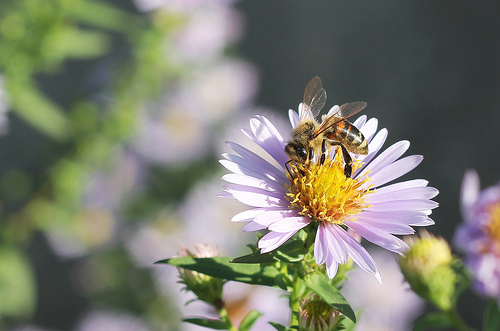

In [9]:
PIL.Image.open(str(flower_dict['daisy'][13]))

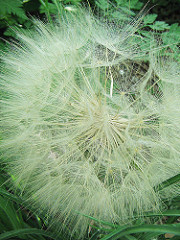

In [10]:
PIL.Image.open(str(flower_dict['dandelion'][4]))

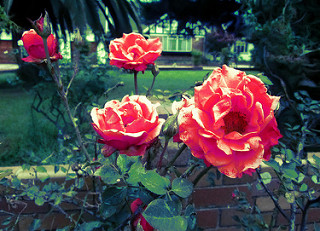

In [11]:
PIL.Image.open(str(flower_dict['roses'][24]))

In [12]:
img = cv2.imread(str(flower_dict['roses'][1]))
img

array([[[10, 16, 15],
        [17, 22, 21],
        [15, 17, 17],
        ...,
        [ 0,  2,  2],
        [ 0,  2,  2],
        [ 0,  1,  1]],

       [[15, 21, 20],
        [ 9, 14, 13],
        [ 4,  6,  6],
        ...,
        [ 0,  2,  2],
        [ 0,  2,  2],
        [ 0,  2,  2]],

       [[16, 22, 21],
        [ 7, 12, 11],
        [ 0,  5,  4],
        ...,
        [ 0,  2,  2],
        [ 0,  2,  2],
        [ 0,  2,  2]],

       ...,

       [[ 0,  2,  2],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  1,  1],
        [ 0,  2,  2],
        [ 0,  2,  2]],

       [[ 1,  3,  3],
        [ 0,  2,  2],
        [ 0,  2,  2],
        ...,
        [ 0,  2,  2],
        [ 0,  2,  2],
        [ 0,  2,  2]],

       [[ 3,  5,  5],
        [ 3,  5,  5],
        [ 4,  6,  6],
        ...,
        [ 0,  2,  2],
        [ 1,  3,  3],
        [ 1,  3,  3]]], shape=(240, 320, 3), dtype=uint8)

In [13]:
img.shape

(240, 320, 3)

In [14]:
inputs, target = [], []

for flower, images in flower_dict.items():
    for img in images:
        image = cv2.imread(str(img))
        
        if image is not None:
            resized_image = cv2.resize(image, (180, 180))
            inputs.append(resized_image)
            target.append(flower_num_dict[flower])

In [15]:
inputs = np.array(inputs)
target = np.array(target)
inputs[1], int(target[1])

(array([[[223, 215, 214],
         [221, 215, 207],
         [225, 214, 215],
         ...,
         [ 15,  12,   8],
         [ 17,  11,  13],
         [ 11,   7,   7]],
 
        [[226, 219, 216],
         [227, 220, 217],
         [227, 219, 218],
         ...,
         [ 12,  10,  10],
         [ 12,   6,   8],
         [ 14,  10,   9]],
 
        [[229, 222, 222],
         [227, 218, 218],
         [235, 230, 224],
         ...,
         [ 17,  15,  15],
         [ 13,   7,   8],
         [ 13,   8,   7]],
 
        ...,
 
        [[196, 190, 190],
         [205, 200, 200],
         [213, 209, 208],
         ...,
         [150, 160, 168],
         [161, 172, 180],
         [161, 170, 182]],
 
        [[227, 223, 218],
         [228, 223, 216],
         [232, 226, 220],
         ...,
         [148, 158, 168],
         [163, 173, 182],
         [159, 169, 176]],
 
        [[238, 232, 230],
         [235, 227, 226],
         [238, 231, 228],
         ...,
         [149, 161, 172],
  

In [16]:
inputs = inputs/255

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(inputs, target, test_size= 0.2, random_state= 42)

In [18]:
X_train[0], int(y_train[0])

(array([[[0.0745098 , 0.21176471, 0.18823529],
         [0.0745098 , 0.21568627, 0.19215686],
         [0.08627451, 0.21176471, 0.19215686],
         ...,
         [0.32156863, 0.39607843, 0.42745098],
         [0.31372549, 0.38431373, 0.41568627],
         [0.3254902 , 0.38039216, 0.41176471]],
 
        [[0.08235294, 0.22352941, 0.2       ],
         [0.08235294, 0.22352941, 0.2       ],
         [0.09019608, 0.22745098, 0.20392157],
         ...,
         [0.31764706, 0.41568627, 0.44705882],
         [0.30588235, 0.39607843, 0.42745098],
         [0.31372549, 0.39215686, 0.41960784]],
 
        [[0.09019608, 0.23921569, 0.21568627],
         [0.08627451, 0.23529412, 0.21176471],
         [0.08627451, 0.23921569, 0.21176471],
         ...,
         [0.32156863, 0.43137255, 0.46666667],
         [0.30588235, 0.41568627, 0.44313725],
         [0.30980392, 0.4       , 0.43137255]],
 
        ...,
 
        [[0.22745098, 0.38039216, 0.34901961],
         [0.07058824, 0.18039216, 0.15686

In [19]:
from tensorflow.keras import layers

In [20]:
data_augmentation =  keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.1),
    layers.RandomRotation(0.1),
])

In [28]:
CNN_model = keras.models.Sequential([
    data_augmentation,
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(5)
])

CNN_model.compile(optimizer= 'adam',
              loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics= ['accuracy'])
              
CNN_model.fit(X_train, y_train, epochs=30)              

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 135ms/step - accuracy: 0.3362 - loss: 1.6057
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.4775 - loss: 1.2127
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.5276 - loss: 1.1222
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 142ms/step - accuracy: 0.5634 - loss: 1.0724
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.6107 - loss: 0.9980
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 143ms/step - accuracy: 0.6277 - loss: 0.9543
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - accuracy: 0.6587 - loss: 0.8855
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - accuracy: 0.6696 - loss: 0.8569
Epoch 9/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.6853 - loss: 0.8025
Epoch 10/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.6993 - loss: 0.7855
Epoch 11/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - accuracy: 0.7139 - loss: 0.7286
Epoch 12/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13

In [29]:
CNN_model.evaluate(X_test, y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7193 - loss: 0.8614


[0.8614335060119629, 0.7193460464477539]

In [30]:
CNN_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 90, 90, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 30976)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,965,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,967,857 (45.65 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,978,572 (30.44 MB)

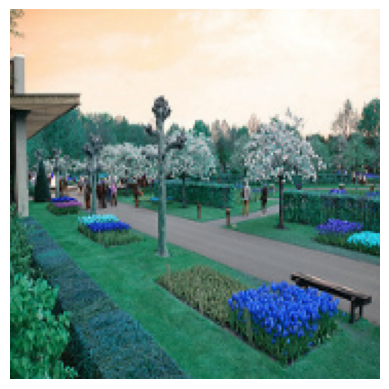

In [31]:
import matplotlib.pyplot as plt

plt.imshow(X_test[2])
plt.axis("off")
plt.show()

In [32]:
print(y_test[1])

3


In [33]:
from sklearn.metrics import confusion_matrix, classification_report

y_prediction = CNN_model.predict(X_test)
y_predict= np.argmax(y_prediction, axis=1)
cm = confusion_matrix(y_test, y_predict)
cm

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


array([[112,  20,   9,   4,   5],
       [ 12, 139,   3,  10,   2],
       [  8,  17,  93,   4,  10],
       [  4,  21,   3, 100,   1],
       [  9,   9,  44,  11,  84]])

<function matplotlib.pyplot.show(close=None, block=None)>

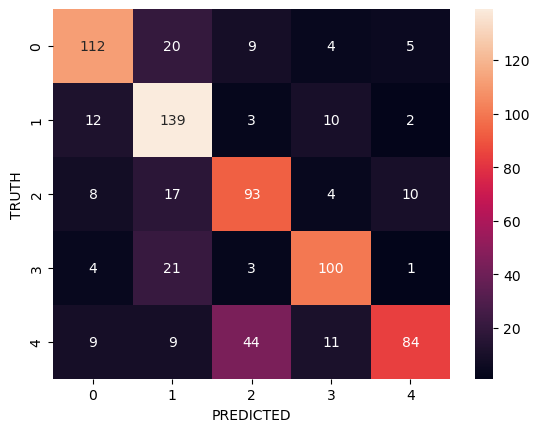

In [34]:
import seaborn as sn

sn.heatmap(cm, annot= True, fmt= 'd')
plt.ylabel('TRUTH')
plt.xlabel('PREDICTED')
plt.show